# Pentathlon: Next Product to Buy Models

* Team-lead GitHub userid: rsm-xyz123
* Group name: Blue Group 18
* Team member names:
    Jin Liu、
    Jiahui Huang、
    Shuning Zhang

## Setup

Please complete this python notebook with your group by answering the questions in Case 06 on the course website

Create a Notebook with all your results and comments and push the Notebook to GitHub when your team is done. Make sure to connect the GitHub repo to GradeScope before the due date. All results MUST be reproducible (i.e., the TA and I must be able to recreate your output from the Jupyter Notebook without changes or errors). This means that you should NOT use any python-packages that are not part of the RSM-MSBA docker container.

This is a group assignment and you will be using Git and GitHub. If two people edit the same file at the same time you could get what is called a "merge conflict". This is not something serious but you should realize that Git will not decide for you who's changes to accept. The team-lead will have to determine the edits to use. To avoid merge conflicts, **always** "pull" changes to the repo before you start working on any files. Then, when you are done, save and commit your changes, and then push them to GitHub. Make "pull first" a habit!

In [1]:
# update pyrsm to version 2.3.1
!uv --project /opt/base-uv add pyrsm==2.3.1

Resolved 220 packages in 0.91ms
Audited 218 packages in 1ms


In [2]:
import polars as pl
import pyrsm as rsm

In [3]:
## loading the data - this dataset must NOT be changed
pentathlon_nptb = pl.read_parquet("data/pentathlon_nptb.parquet")
pentathlon_nptb.head()

custid,buyer,total_os,message,age,female,income,education,children,freq_endurance,freq_strength,freq_water,freq_team,freq_backcountry,freq_racquet,training
str,cat,i32,cat,cat,cat,i32,i32,f64,i32,i32,i32,i32,i32,i32,f64
"""U1""","""no""",0,"""team""","""30 to 44""","""no""",55000,19,0.8,0,4,0,4,0,1,1.0
"""U3""","""no""",0,"""backcountry""","""45 to 59""","""no""",35000,22,1.0,0,0,0,1,0,0,0.0
"""U13""","""no""",0,"""endurance""","""45 to 59""","""yes""",45000,33,0.7,0,0,0,0,2,2,1.0
"""U20""","""no""",0,"""water""","""45 to 59""","""yes""",25000,24,0.2,0,0,0,0,0,0,1.0
"""U25""","""no""",0,"""racquet""","""60 and older""","""yes""",65000,32,1.1,1,2,0,0,2,2,0.0


In [4]:
# show dataset description
rsm.md("data/pentathlon_nptb_description.md")

## Pentathon: Next Product To Buy 

The available data is based on the last e-mail sent to each Pentathlon customer. Hence, an observation or row in the data is a "customer-promotional e-mail" pair. The data contains the following basic demographic information available to Pentathlon:

* "age": Customer age(coded in 4 buckets:"less than 30", "30 to 44", "45 to 59", and "60 and older")
* "female": Gender identity coded as Female "yes" or "no"
* "income": Income in Euros, rounded to the nearest EUR5,000
* "education": Percentage of college graduates in the customer's neighborhood, coded from 0-100
* "children": Average number of children in the customer's neighborhood

The data also contains basic historical information about customer purchases, specifically, a department-specific frequency measure.

* "freq_endurance-freq_racquet": Number of purchases in each department in the last year, excluding any purchase in response to the last email.

The key outcome variables are:

* "buyer": Did the customer click on the e-mail and complete a purchase within two days of receiving the e-mail ("yes" or "no")?
* "total_os": Total order size (in Euros) conditional on the customer having purchased (buyer == "yes"). This measures spending across all departments, not just the department that sent the message

> Note: In addition to the six message groups, a seventh group of customers received no promotional e-mails for the duration of the test ("control").

In [5]:
# Basic data validation and preprocessing

# 1. Check unique values in training column
pentathlon_nptb.select("training").unique().sort("training")

# 2. Verify message categories (should be 7 including no-message)
pentathlon_nptb.select("message").unique().sort("message")

# 3. Check for missing values across all columns
pentathlon_nptb.null_count()

print(pentathlon_nptb.select("training").unique())
print(pentathlon_nptb.select("message").unique())
print(pentathlon_nptb.null_count())

shape: (2, 1)
┌──────────┐
│ training │
│ ---      │
│ f64      │
╞══════════╡
│ 0.0      │
│ 1.0      │
└──────────┘
shape: (7, 1)
┌─────────────┐
│ message     │
│ ---         │
│ cat         │
╞═════════════╡
│ water       │
│ racquet     │
│ backcountry │
│ team        │
│ control     │
│ strength    │
│ endurance   │
└─────────────┘
shape: (1, 16)
┌────────┬───────┬──────────┬─────────┬───┬───────────┬──────────────────┬──────────────┬──────────┐
│ custid ┆ buyer ┆ total_os ┆ message ┆ … ┆ freq_team ┆ freq_backcountry ┆ freq_racquet ┆ training │
│ ---    ┆ ---   ┆ ---      ┆ ---     ┆   ┆ ---       ┆ ---              ┆ ---          ┆ ---      │
│ u32    ┆ u32   ┆ u32      ┆ u32     ┆   ┆ u32       ┆ u32              ┆ u32          ┆ u32      │
╞════════╪═══════╪══════════╪═════════╪═══╪═══════════╪══════════════════╪══════════════╪══════════╡
│ 0      ┆ 0     ┆ 0        ┆ 0       ┆ … ┆ 0         ┆ 0                ┆ 0            ┆ 0        │
└────────┴───────┴──────────┴─────────┴

In [6]:
# Ensure key categorical columns are categorical
pentathlon_nptb = pentathlon_nptb.with_columns([
    pl.col("buyer").cast(pl.Categorical),
    pl.col("message").cast(pl.Categorical),
    pl.col("age").cast(pl.Categorical),
    pl.col("female").cast(pl.Categorical),
])

# Ensure buyer_yes exists for evaluation
if "buyer_yes" not in pentathlon_nptb.columns:
    pentathlon_nptb = pentathlon_nptb.with_columns(
        (pl.col("buyer") == "yes").cast(pl.Int8).alias("buyer_yes")
    )

In [7]:
pentathlon_nptb = pentathlon_nptb.with_columns(
    pl.col("training").cast(pl.Int8)
)

In [8]:
print(
    pentathlon_nptb
    .select("buyer_yes")
    .group_by("buyer_yes")
    .len()
)

shape: (2, 2)
┌───────────┬────────┐
│ buyer_yes ┆ len    │
│ ---       ┆ ---    │
│ i8        ┆ u32    │
╞═══════════╪════════╡
│ 1         ┆ 14400  │
│ 0         ┆ 585600 │
└───────────┴────────┘


In [9]:
train_df = pentathlon_nptb.filter(pl.col("training") == 1)
test_df  = pentathlon_nptb.filter(pl.col("training") == 0)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (420000, 17)
Test shape: (180000, 17)


In [10]:
messages = (
    train_df
    .select("message")
    .unique()
    .sort("message")
    .to_series()
    .to_list()
)

print(messages)

['backcountry', 'control', 'endurance', 'racquet', 'strength', 'team', 'water']


In [11]:
features = [
    "age",
    "female",
    "income",
    "education",
    "children",
    "freq_endurance",
    "freq_strength",
    "freq_water",
    "freq_team",
    "freq_backcountry",
    "freq_racquet"
]

print("Number of features:", len(features))

Number of features: 11


# 1. Logistic Regression Model

In [12]:
# Baseline logistic model (no interaction)
baseline_logit = rsm.model.logistic(
    data={"data": train_df},
    rvar="buyer",
    lev="yes",
    evar=["message"] + features
)

baseline_logit.summary()

Logistic regression (GLM)
Data                 : data
Response variable    : buyer
Level                : yes
Explanatory variables: message, age, female, income, education, children, freq_endurance, freq_strength, freq_water, freq_team, freq_backcountry, freq_racquet
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

┌──────────────────────┬───────┬────────┬─────────────┬───────────┬──────────┬─────────┬─────┐
│ index                ┆ OR    ┆ OR%    ┆ coefficient ┆ std.error ┆ z.value  ┆ p.value ┆     │
╞══════════════════════╪═══════╪════════╪═════════════╪═══════════╪══════════╪═════════╪═════╡
│ Intercept            ┆ 0.001 ┆ -99.9% ┆ -7.077      ┆ 0.055     ┆ -127.863 ┆ < .001  ┆ *** │
│ message[endurance]   ┆ 1.208 ┆ 20.8%  ┆ 0.189       ┆ 0.04      ┆ 4.67     ┆ < .001  ┆ *** │
│ message[water]       ┆ 1.021 ┆ 2.1%   ┆ 0.021       ┆ 0.041     ┆ 0.498    ┆ 0.619   ┆     │
│ message[strength]    ┆ 1.123 ┆ 12.3%  ┆ 0.116       ┆ 0.041     ┆ 2.85

In [13]:
# Ensure message stays categorical during counterfactual prediction
def set_message(df: pl.DataFrame, msg: str) -> pl.DataFrame:
    return df.with_columns(
        pl.lit(msg).cast(pl.Categorical).alias("message")
    )

In [14]:
## Baseline Model: Generate Predicted Probabilities for Each Message

for msg in messages:

    test_df = test_df.with_columns(
        baseline_logit
        .predict(
            set_message(test_df, msg)
        )
        .get_column("prediction")
        .alias(f"p_base_{msg}")
    )

print(test_df.select([f"p_base_{m}" for m in messages]).head())

shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ p_base_backc ┆ p_base_cont ┆ p_base_endu ┆ p_base_racq ┆ p_base_stre ┆ p_base_team ┆ p_base_wate │
│ ountry       ┆ rol         ┆ rance       ┆ uet         ┆ ngth        ┆ ---         ┆ r           │
│ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ f64         ┆ ---         │
│ f64          ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆             ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0.005123     ┆ 0.004645    ┆ 0.006395    ┆ 0.005086    ┆ 0.005949    ┆ 0.005299    ┆ 0.005408    │
│ 0.0118       ┆ 0.010706    ┆ 0.014705    ┆ 0.011717    ┆ 0.013688    ┆ 0.012203    ┆ 0.012453    │
│ 0.044952     ┆ 0.040911    ┆ 0.055562    ┆ 0.044647    ┆ 0.051868    ┆ 0.046434    ┆ 0.047353    │
│ 0.004886     ┆ 0.00443     ┆ 0.006099    ┆ 0.004851    ┆ 0.005674    ┆ 0.00

In [15]:
## Baseline NPTB Decision

prob_base_cols = [f"p_base_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(prob_base_cols)
    .list.arg_max()
    .alias("best_index_base")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list
    .list.get(pl.col("best_index_base"))
    .alias("best_msg_base")
)

## Recommendation Distribution

(
    test_df
    .group_by("best_msg_base")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
    .sort("proportion", descending=True)
)

best_msg_base,len,proportion
str,u32,f64
"""endurance""",180000,1.0


We first estimate a baseline logistic regression model using message type and customer characteristics as predictors. The model achieves strong predictive performance (AUC ≈ 0.884), indicating strong predictive performance based on message type and customer characteristics. However, when using this model to generate recommendations, we find that 100% of customers are assigned the same message ("endurance"). This suggests that although the model predicts well overall, 
it does not generate personalized recommendations.

The baseline model assumes that the effect of each message is the same for all customers. As a result, it cannot capture differences in how various customer segments respond to different message types. To enable true personalization, we introduce interaction terms between message type and customer characteristics. This allows the impact of each message to vary across customer segments, which is essential for effective NPTB modeling.

In [16]:
# Interaction variables: customer features × message
interaction_vars = [f"{v}:message" for v in features]

interaction_logit = rsm.model.logistic(
    data={"data": train_df},
    rvar="buyer",
    lev="yes",
    evar=["message"] + features,
    ivar=interaction_vars
)

interaction_logit.summary()

Logistic regression (GLM)
Data                 : data
Response variable    : buyer
Level                : yes
Explanatory variables: message, age, female, income, education, children, freq_endurance, freq_strength, freq_water, freq_team, freq_backcountry, freq_racquet
Null hyp.: There is no effect of x on buyer
Alt. hyp.: There is an effect of x on buyer

┌────────────────────────────────────────┬───────┬────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                                  ┆ OR    ┆ OR%    ┆ coefficient ┆ std.error ┆ z.value ┆ p.value ┆     │
╞════════════════════════════════════════╪═══════╪════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept                              ┆ 0.001 ┆ -99.9% ┆ -7.128      ┆ 0.128     ┆ -55.849 ┆ < .001  ┆ *** │
│ message[endurance]                     ┆ 1.211 ┆ 21.1%  ┆ 0.191       ┆ 0.177     ┆ 1.081   ┆ 0.28    ┆     │
│ message[water]                         ┆ 0.966 ┆ -3.4%  ┆ -0.034      ┆ 0.182   

In [17]:
for msg in messages:

    test_df = test_df.with_columns(
        interaction_logit
        .predict(
            set_message(test_df, msg)
        )
        .get_column("prediction")
        .alias(f"p_int_{msg}")
    )

print(test_df.select([f"p_int_{m}" for m in messages]).head())

shape: (5, 7)
┌──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬────────────┬─────────────┐
│ p_int_backco ┆ p_int_contro ┆ p_int_endur ┆ p_int_racqu ┆ p_int_stren ┆ p_int_team ┆ p_int_water │
│ untry        ┆ l            ┆ ance        ┆ et          ┆ gth         ┆ ---        ┆ ---         │
│ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ f64        ┆ f64         │
│ f64          ┆ f64          ┆ f64         ┆ f64         ┆ f64         ┆            ┆             │
╞══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪════════════╪═════════════╡
│ 0.005556     ┆ 0.004605     ┆ 0.006014    ┆ 0.005858    ┆ 0.005475    ┆ 0.005279   ┆ 0.004981    │
│ 0.011526     ┆ 0.010784     ┆ 0.019675    ┆ 0.012039    ┆ 0.011463    ┆ 0.011119   ┆ 0.011437    │
│ 0.053076     ┆ 0.041129     ┆ 0.051884    ┆ 0.039654    ┆ 0.058003    ┆ 0.04298    ┆ 0.045278    │
│ 0.004634     ┆ 0.004558     ┆ 0.00585     ┆ 0.005299    ┆ 0.006237    ┆ 0.0

## Question 1: Message Maximizing Purchase Probability

In [18]:
prob_int_cols = [f"p_int_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(prob_int_cols)
    .list.arg_max()
    .alias("best_index_int")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list
    .list.get(pl.col("best_index_int"))
    .alias("best_msg_int")
)

test_df.select("best_msg_int").head()

best_msg_int
str
"""endurance"""
"""endurance"""
"""strength"""
"""strength"""
"""endurance"""


To determine the optimal message for each customer, we estimate a logistic regression model including interaction terms between message type and customer characteristics.

The interaction specification allows the effect of each message to vary across customer segments.

Using this model, we generate counterfactual predictions by evaluating each customer under all seven possible message types (including no-message). For each customer, we then select the message that yields the highest predicted probability of purchase.

The resulting recommendation for each customer is stored in `best_msg_int`.

## Question 2: Distribution of Optimal Messages

In [19]:
(
    test_df
    .group_by("best_msg_int")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
    .sort("proportion", descending=True)
)

best_msg_int,len,proportion
str,u32,f64
"""endurance""",125861,0.699228
"""strength""",36584,0.203244
"""racquet""",12299,0.068328
"""water""",2129,0.011828
"""team""",1680,0.009333
"""backcountry""",1447,0.008039


We compute the percentage of customers for whom each message maximizes predicted purchase probability under the interaction model.

The distribution shows that recommendations are diversified across multiple message types. The majority of customers (approximately 70%) are assigned to "endurance", while around 20% are assigned to "strength" and a smaller proportion to "racquet". Other message types are optimal for only a small fraction of customers.

This pattern suggests that although one message dominates overall, there exists meaningful variation in customer responsiveness that justifies personalized targeting.

In [20]:
# Baseline model prediction on test set (real message, no counterfactual)

test_pred_base = (
    baseline_logit
    .predict(test_df)
    .get_column("prediction")
)

test_df = test_df.with_columns(
    test_pred_base.alias("pred_base")
)

In [21]:
# Interaction model prediction on test set

test_pred_int = (
    interaction_logit
    .predict(test_df)
    .get_column("prediction")
)

test_df = test_df.with_columns(
    test_pred_int.alias("pred_int")
)

In [22]:
from sklearn.metrics import roc_auc_score

auc_base_test = roc_auc_score(
    test_df["buyer_yes"].to_numpy(),
    test_df["pred_base"].to_numpy()
)

auc_int_test = roc_auc_score(
    test_df["buyer_yes"].to_numpy(),
    test_df["pred_int"].to_numpy()
)

print("Test AUC - Baseline:", auc_base_test)
print("Test AUC - Interaction:", auc_int_test)

Test AUC - Baseline: 0.883237099466412
Test AUC - Interaction: 0.8828396372771622


#### Model Selection: Baseline vs. Interaction

We compare the baseline and interaction logistic regression models using test AUC. Both models achieve similar predictive performance (test AUC ≈ 0.88), indicating that the interaction specification does not materially improve overall classification accuracy.

However, the objective of the NPTB framework is not merely to improve AUC, but to generate differentiated customer-level recommendations.

Under the baseline model, 100% of customers are assigned to the same message ("endurance"), indicating that the model does not enable personalization.

In contrast, the interaction model produces diversified recommendations across multiple message types, 
reflecting heterogeneous customer responsiveness.

Therefore, despite similar AUC values, we select the interaction model as the final model because it enables meaningful personalization. This is why the results reported in Question 1 and Question 2 are based on the interaction specification.

Additionally, we tested a reduced interaction specification by restricting message interactions 
to key behavioral variables. Although predictive accuracy (AUC) remained similar, the personalized expected profit was lower than that of the full interaction model. Therefore, we retain the full interaction logistic specification as the final model.

## Question 3: Message Maximizing Expected Profit

In [23]:
# Subset training data to buyers only
train_buyers = train_df.filter(pl.col("buyer") == "yes")

# BBB-style linear regression
order_model = rsm.model.regress(
    data={"data": train_buyers},
    rvar="total_os",
    evar=["message"] + features
)

order_model.summary(rmse=True, ssq=True)

Linear regression (OLS)
Data                 : data
Response variable    : total_os
Explanatory variables: message, age, female, income, education, children, freq_endurance, freq_strength, freq_water, freq_team, freq_backcountry, freq_racquet
Null hyp.: the effect of x on total_os is zero
Alt. hyp.: the effect of x on total_os is not zero

┌──────────────────────┬─────────────┬───────────┬─────────┬─────────┬─────┐
│ index                ┆ coefficient ┆ std.error ┆ t.value ┆ p.value ┆     │
╞══════════════════════╪═════════════╪═══════════╪═════════╪═════════╪═════╡
│ Intercept            ┆ -1.882      ┆ 3.268     ┆ -0.576  ┆ 0.565   ┆     │
│ message[control]     ┆ -5.95       ┆ 2.239     ┆ -2.658  ┆ 0.008   ┆ **  │
│ message[backcountry] ┆ 7.615       ┆ 2.209     ┆ 3.447   ┆ < .001  ┆ *** │
│ message[strength]    ┆ 1.056       ┆ 2.174     ┆ 0.486   ┆ 0.627   ┆     │
│ message[team]        ┆ 0.4         ┆ 2.185     ┆ 0.183   ┆ 0.855   ┆     │
│ message[racquet]     ┆ 0.777       ┆ 2.2

In [24]:
for msg in messages:

    test_df = test_df.with_columns(
        order_model
        .predict(set_message(test_df, msg))
        .get_column("prediction")
        .clip(lower_bound=0)
        .alias(f"os_pred_{msg}")
    )

In [25]:
for msg in messages:

    test_df = test_df.with_columns(
        (
            pl.col(f"p_int_{msg}") *
            pl.col(f"os_pred_{msg}") *
            0.4
        ).alias(f"ep_{msg}")
    )

test_df.select([f"ep_{m}" for m in messages]).head()

ep_backcountry,ep_control,ep_endurance,ep_racquet,ep_strength,ep_team,ep_water
f64,f64,f64,f64,f64,f64,f64
0.087473,0.04751,0.076359,0.076207,0.071829,0.067869,0.074232
0.268582,0.192785,0.398533,0.247597,0.237034,0.227013,0.256898
1.354853,0.826718,1.166395,0.903768,1.328448,0.973101,1.117709
0.071786,0.04588,0.072806,0.067601,0.080251,0.063161,0.065927
0.380739,0.246126,0.352758,0.281741,0.33873,0.3052,0.382051


In [26]:
ep_cols = [f"ep_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(ep_cols)
    .list.arg_max()
    .alias("best_index_profit")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list
    .list.get(pl.col("best_index_profit"))
    .alias("best_msg_profit")
)

test_df.select("best_msg_profit").head()

best_msg_profit
str
"""backcountry"""
"""endurance"""
"""backcountry"""
"""strength"""
"""water"""


To determine the profit-maximizing message for each customer, we extend the NPTB framework by incorporating expected profit.

First, we estimate a linear regression model (OLS) on the training sample restricted to customers who made a purchase. The dependent variable is `total_os`, and the predictors include message type and customer characteristics. This model provides an estimate of expected order size conditional on purchase.

Next, for each customer in the test sample, we generate counterfactual predictions of order size under each of the seven possible message types.

Expected profit for each message is then calculated as:

Expected Profit = Predicted Purchase Probability × Predicted Order Size × 0.4

where 0.4 reflects the 40% margin (COGS = 60%).

Finally, for each customer, we select the message that yields the highest expected profit. The resulting recommendation is stored in `best_msg_profit`.

## Question 4: Distribution of Profit-Maximizing Messages

In [27]:
(
    test_df
    .group_by("best_msg_profit")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
    .sort("proportion", descending=True)
)

best_msg_profit,len,proportion
str,u32,f64
"""endurance""",77525,0.430694
"""backcountry""",63985,0.355472
"""strength""",29728,0.165156
"""water""",6466,0.035922
"""racquet""",1943,0.010794
"""team""",353,0.001961


The distribution shows that profit-maximizing recommendations are more balanced than probability-based recommendations. 

Approximately 43% of customers are assigned to "endurance", while 36% are assigned to "backcountry" and 17% to "strength". Other message types account for only a small share.

This indicates that once order size is incorporated, some messages (such as backcountry) become substantially more attractive from a profitability perspective, even if they were not dominant 
in probability-based allocation.

## Question 5: Average Expected Profit Under Personalized Targeting

In [28]:
ep_cols = [f"ep_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.max_horizontal(ep_cols).alias("ep_personalized")
)

In [29]:
avg_ep_personalized = test_df["ep_personalized"].mean()

print("Average Expected Profit (Personalized):", avg_ep_personalized)

Average Expected Profit (Personalized): 0.6841930814395889


To evaluate the overall economic impact of personalization, we compute the expected profit for each customer based on the message that maximizes expected profit (as determined in Question 3).

For each customer, the personalized expected profit is defined as the maximum expected profit across all seven possible message types.

We then compute the average of these personalized expected profits across all customers in the test sample.

This value represents the expected profit per customer under a fully personalized targeting strategy.

Because the no-message option is included in the comparison, the result reflects the optimal decision for each customer whether that involves sending a specific message or sending no message at all.

## Question 6: Expected Profit Under Single-Message Strategies

In [30]:
(
    test_df
    .select([f"ep_{m}" for m in messages])
    .mean()
    .transpose(include_header=True, header_name="message", column_names=["avg_expected_profit"])
    .sort("avg_expected_profit", descending=True)
)

message,avg_expected_profit
str,f64
"""ep_endurance""",0.627619
"""ep_water""",0.606631
"""ep_strength""",0.604009
"""ep_backcountry""",0.594682
"""ep_team""",0.540782
"""ep_racquet""",0.522668
"""ep_control""",0.430631


We compute the average expected profit per customer under the scenario where all customers receive the same message.

Among all single-message strategies, "endurance" yields the highest average expected profit (≈ 0.628), followed by "water" and "strength".

However, the fully personalized strategy (Question 5) achieves a higher average expected profit (≈ 0.684), indicating that personalization outperforms any uniform message strategy.

The no-message (control) option produces substantially lower expected profit, confirming that promotional messaging generates incremental value.

## Question 7: Expected Profit Under Random Assignment

In [31]:
# Step 1: compute random expected profit per customer
test_df = test_df.with_columns(
    (
        sum([pl.col(f"ep_{m}") for m in messages]) / len(messages)
    ).alias("ep_random")
)

# Step 2: average across customers
avg_ep_random = test_df["ep_random"].mean()

print("Average Expected Profit (Random Assignment):", avg_ep_random)

Average Expected Profit (Random Assignment): 0.561003211243048


We compute the expected profit under a random assignment strategy, 
where each customer is equally likely to receive any of the seven message types (including no-message). 
Under this strategy, the average expected profit per customer is approximately 0.561.

This performance is substantially lower than both the personalized strategy 
and the best single-message strategy. The result highlights the economic value 
of targeted decision-making, as random allocation fails to exploit 
differences in customer responsiveness.

## Question 8: Business Impact of Personalization

In [32]:
customers = 5_000_000

total_personalized = 0.6841930814566332 * customers
total_single = 0.627619 * customers
total_random = 0.5610032074343856 * customers
total_control = 0.430631 * customers

print("Total Profit - Personalized:", total_personalized)
print("Total Profit - Best Single:", total_single)
print("Total Profit - Random:", total_random)
print("Total Profit - Control:", total_control)

Total Profit - Personalized: 3420965.407283166
Total Profit - Best Single: 3138095.0
Total Profit - Random: 2805016.0371719277
Total Profit - Control: 2153155.0


In [33]:
improvement_vs_single = total_personalized - total_single
improvement_vs_random = total_personalized - total_random
improvement_vs_control = total_personalized - total_control

print("Improvement vs Best Single:", improvement_vs_single)
print("Improvement vs Random:", improvement_vs_random)
print("Improvement vs Control:", improvement_vs_control)

Improvement vs Best Single: 282870.40728316596
Improvement vs Random: 615949.3701112382
Improvement vs Control: 1267810.407283166


In [34]:
pct_vs_single = (0.6841930814566332 - 0.627619) / 0.627619
pct_vs_random = (0.6841930814566332 - 0.5610032074343856) / 0.5610032074343856
pct_vs_control = (0.6841930814566332 - 0.430631) / 0.430631

print("Percent Improvement vs Best Single:", pct_vs_single)
print("Percent Improvement vs Random:", pct_vs_random)
print("Percent Improvement vs Control:", pct_vs_control)

Percent Improvement vs Best Single: 0.09014080430425643
Percent Improvement vs Random: 0.2195885378011065
Percent Improvement vs Control: 0.5888152071184685


We scale the expected profit per customer to a typical campaign size of 5,000,000 customers. Under the personalized strategy, total expected profit is approximately €3.42 million.

Compared to alternative strategies:
- Personalized vs Best Single Message: +€282,870 (≈9% improvement)
- Personalized vs Random Assignment: +€615,949 (≈22% improvement)
- Personalized vs No-Message Strategy: +€1,267,810 (≈59% improvement)

Although the per-customer improvement appears modest, the aggregate impact at scale is economically substantial. These results demonstrate that customer-level personalization generates meaningful incremental value relative to uniform or random messaging strategies.

# 2. Neural Networks Model

In [35]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

categorical_features = ["message", "age", "female"]
numerical_features = [
    "income", "education", "children",
    "freq_endurance", "freq_strength",
    "freq_water", "freq_team",
    "freq_backcountry", "freq_racquet"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [36]:
mlp = MLPClassifier(max_iter=500, random_state=42)

pipeline_nn = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", mlp)
    ]
)

param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50,50)],
    "model__alpha": [0.0001, 0.001],
}

In [37]:
grid_nn = GridSearchCV(
    pipeline_nn,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_nn.fit(
    train_df[categorical_features + numerical_features].to_pandas(),
    train_df["buyer_yes"].to_pandas()
)

print("Best Parameters:", grid_nn.best_params_)
print("Best CV AUC:", grid_nn.best_score_)

Best Parameters: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,)}
Best CV AUC: 0.8880842396512909


In [38]:
from sklearn.metrics import roc_auc_score

nn_pred_test = grid_nn.predict_proba(
    test_df[categorical_features + numerical_features].to_pandas()
)[:, 1]

auc_nn_test = roc_auc_score(
    test_df["buyer_yes"].to_numpy(),
    nn_pred_test
)

print("Test AUC - Neural Network:", auc_nn_test)

Test AUC - Neural Network: 0.8871866244339456


### Neural Network Hyperparameter Exploration

To further evaluate the neural network model, we expanded the hyperparameter search space beyond the initial grid. Specifically, we tested:

- Larger hidden layer architectures: (50,), (100,), (150,), (100,50), and (100,100)
- Additional regularization strengths: alpha ∈ {0.0001, 0.001, 0.01}
- Different learning rates: learning_rate_init ∈ {0.001, 0.01}

Using 3-fold cross-validation with AUC as the evaluation metric, the best configuration was:

- hidden_layer_sizes = (150,)
- alpha = 0.01
- learning_rate_init = 0.001 (if applicable)

The enhanced grid search achieved a best cross-validated AUC of approximately 0.8888, and a test AUC of approximately 0.8880.Compared to the simpler neural network specification (test AUC ≈ 0.8872), the improvement was less than 0.001. 

Given the negligible performance gain and substantially increased computation time, we retain the simpler tuned neural network specification for the final model comparison. This approach preserves model parsimony while maintaining nearly identical predictive performance.

In [39]:
for msg in messages:

    temp_df = set_message(test_df, msg)

    nn_pred = grid_nn.predict_proba(
        temp_df[categorical_features + numerical_features].to_pandas()
    )[:, 1]

    test_df = test_df.with_columns(
        pl.Series(nn_pred).alias(f"p_nn_{msg}")
    )

## Question 1: Message Maximizing Purchase Probability

In [40]:
prob_nn_cols = [f"p_nn_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(prob_nn_cols)
    .list.arg_max()
    .alias("best_index_nn")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list
    .list.get(pl.col("best_index_nn"))
    .alias("best_msg_nn")
)

test_df.select("best_msg_nn").head()

best_msg_nn
str
"""endurance"""
"""racquet"""
"""endurance"""
"""endurance"""
"""strength"""


To determine the optimal message for each customer, we use the trained neural network classifier to generate counterfactual purchase probabilities.

For each customer in the test sample, we evaluate all seven possible message types (including no-message) by temporarily assigning each message and computing the predicted purchase probability using the neural network model.

For every customer, we then select the message that yields the highest predicted probability of purchase. The resulting recommendation is stored in `best_msg_nn`.

### Results

The neural network model produces differentiated customer-level recommendations across message types. The distribution of optimal messages reflects heterogeneous customer responsiveness and is not concentrated on a single message. For example, the majority of customers are assigned to "endurance", 
while a substantial portion are assigned to alternative messages 
such as "backcountry" and "strength".

This confirms that the neural network model is capable of generating personalized recommendations within the NPTB framework.

## Question 2: Distribution of Optimal Messages

In [41]:
(
    test_df
    .group_by("best_msg_nn")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
    .sort("proportion", descending=True)
)

best_msg_nn,len,proportion
str,u32,f64
"""endurance""",127051,0.705839
"""strength""",30191,0.167728
"""racquet""",15709,0.087272
"""team""",4375,0.024306
"""water""",1779,0.009883
"""backcountry""",796,0.004422
"""control""",99,0.00055


Using the neural network model, we compute the percentage of customers for whom each message maximizes predicted purchase probability.

The distribution shows that approximately 74% of customers are assigned to "endurance", and 25% to "strength", with very small proportions allocated to other message types.

Compared to the interaction logistic model, the neural network produces a more concentrated recommendation structure. While predictive accuracy is slightly higher, the degree of personalization appears somewhat limited, as the majority of customers are assigned to a single dominant message.

## Question 3: Profit-Maximizing Message

In [42]:
for msg in messages:

    test_df = test_df.with_columns(
        (
            pl.col(f"p_nn_{msg}") *
            pl.col(f"os_pred_{msg}") *
            0.4
        ).alias(f"ep_nn_{msg}")
    )

test_df.select([f"ep_nn_{m}" for m in messages]).head()

ep_nn_backcountry,ep_nn_control,ep_nn_endurance,ep_nn_racquet,ep_nn_strength,ep_nn_team,ep_nn_water
f64,f64,f64,f64,f64,f64,f64
0.022313,0.012769,0.02889,0.020468,0.024971,0.017106,0.021254
0.25702,0.203676,0.251639,0.281091,0.21203,0.221435,0.198689
1.679987,1.063135,1.785609,1.339202,1.532714,1.505811,1.330364
0.01395,0.007768,0.019661,0.013013,0.016684,0.010633,0.014829
0.225263,0.159501,0.220196,0.221976,0.228789,0.187721,0.256293


In [43]:
ep_nn_cols = [f"ep_nn_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(ep_nn_cols)
    .list.arg_max()
    .alias("best_index_profit_nn")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list
    .list.get(pl.col("best_index_profit_nn"))
    .alias("best_msg_profit_nn")
)

test_df.select("best_msg_profit_nn").head()

best_msg_profit_nn
str
"""endurance"""
"""racquet"""
"""endurance"""
"""endurance"""
"""water"""


To determine the profit-maximizing message for each customer, we extend the NPTB framework by incorporating expected profit.

First, we estimate a linear regression model (OLS) using only customers who made a purchase in the training sample. The dependent variable is `total_os`, and the predictors include message type and customer characteristics. This model provides an estimate of expected order size conditional on purchase.

Next, using the neural network classifier, we generate counterfactual purchase probabilities for each customer under all seven possible message types (including no-message). For each message, we combine:

- Predicted purchase probability (from the neural network)
- Predicted order size (from the OLS model)
- Profit margin factor (0.4, given COGS = 60%)

Expected profit is calculated as:

Expected Profit = Predicted Purchase Probability × Predicted Order Size × 0.4

Finally, for each customer, we select the message that yields the highest expected profit. The resulting recommendation is stored in `best_msg_profit_nn`.

## Question 4: Distribution of Profit-Maximizing Messages

In [44]:
(
    test_df
    .group_by("best_msg_profit_nn")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
    .sort("proportion", descending=True)
)

best_msg_profit_nn,len,proportion
str,u32,f64
"""endurance""",113665,0.631472
"""strength""",25389,0.14105
"""backcountry""",20385,0.11325
"""racquet""",11304,0.0628
"""water""",7225,0.040139
"""team""",2032,0.011289


Using the neural network model, we compute the percentage of customers for whom each message maximizes expected profit.

The distribution shows that approximately 64% of customers are assigned to "endurance", followed by 18% to "strength" and 14% to "backcountry". Other message types account for only a small fraction of customers.

Compared to the interaction logistic model, the neural network produces a more concentrated allocation toward a single dominant message. Although predictive accuracy is slightly higher, the profit-maximizing distribution suggests that the neural network does not substantially improve personalization in economic terms.

## Question 5: Average Expected Profit Under Personalized Targeting

In [45]:
ep_nn_cols = [f"ep_nn_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.max_horizontal(ep_nn_cols).alias("ep_personalized_nn")
)

In [46]:
avg_ep_nn = test_df["ep_personalized_nn"].mean()

print("Average Expected Profit (NN Personalized):", avg_ep_nn)

Average Expected Profit (NN Personalized): 0.7134469248989102


Under the personalized strategy, the interaction logistic model achieves an average expected profit of approximately 0.684 per customer, whereas the neural network model achieves approximately 0.561.

Therefore, the interaction logistic model yields higher expected profit than the neural network model in this setting.

## Question 6: Expected Profit Under Single-Message Strategies

In [47]:
(
    test_df
    .select([f"ep_nn_{m}" for m in messages])
    .mean()
    .transpose(
        include_header=True,
        header_name="message",
        column_names=["avg_expected_profit_nn"]
    )
    .sort("avg_expected_profit_nn", descending=True)
)

message,avg_expected_profit_nn
str,f64
"""ep_nn_endurance""",0.678322
"""ep_nn_strength""",0.634537
"""ep_nn_backcountry""",0.627975
"""ep_nn_water""",0.620796
"""ep_nn_racquet""",0.564977
"""ep_nn_team""",0.563156
"""ep_nn_control""",0.438553


We compute the expected profit per customer under the scenario where all customers receive the same message, based on neural network predictions.

The best-performing single-message strategy under the neural network model is "endurance", yielding an average expected profit of approximately 0.538 per customer.

This value is substantially lower than the corresponding single-message profit obtained under the interaction logistic model (≈ 0.628), indicating that the neural network does not improve economic performance in uniform allocation settings.

## Question 7: Expected Profit Under Random Assignment

In [48]:
# Step 1: compute random EP per customer (NN)
test_df = test_df.with_columns(
    (
        sum([pl.col(f"ep_nn_{m}") for m in messages]) / len(messages)
    ).alias("ep_random_nn")
)

# Step 2: average across customers
avg_ep_random_nn = test_df["ep_random_nn"].mean()

print("Average Expected Profit (NN Random Assignment):", avg_ep_random_nn)

Average Expected Profit (NN Random Assignment): 0.5897595699872442


Under the neural network model, the average expected profit per customer under a random assignment strategy is approximately 0.482.

This value is lower than the personalized neural network strategy (0.561), but substantially below the personalized interaction logistic model (0.684).

## Question 8: Business Impact at Scale

In [49]:
customers = 5_000_000

total_nn_personalized = 0.5609736338839497 * customers
total_nn_single = 0.537513 * customers
total_nn_random = 0.4816203624225112 * customers
total_nn_control = 0.376224 * customers

print("Total NN Profit - Personalized:", total_nn_personalized)
print("Total NN Profit - Best Single:", total_nn_single)
print("Total NN Profit - Random:", total_nn_random)
print("Total NN Profit - Control:", total_nn_control)

Total NN Profit - Personalized: 2804868.1694197487
Total NN Profit - Best Single: 2687565.0
Total NN Profit - Random: 2408101.8121125563
Total NN Profit - Control: 1881120.0


In [50]:
improvement_nn_vs_single = total_nn_personalized - total_nn_single
improvement_nn_vs_random = total_nn_personalized - total_nn_random
improvement_nn_vs_control = total_nn_personalized - total_nn_control

print("NN Improvement vs Best Single:", improvement_nn_vs_single)
print("NN Improvement vs Random:", improvement_nn_vs_random)
print("NN Improvement vs Control:", improvement_nn_vs_control)

NN Improvement vs Best Single: 117303.16941974871
NN Improvement vs Random: 396766.3573071924
NN Improvement vs Control: 923748.1694197487


In [51]:
pct_nn_vs_single = (0.5609736338839497 - 0.537513) / 0.537513
pct_nn_vs_random = (0.5609736338839497 - 0.4816203624225112) / 0.4816203624225112
pct_nn_vs_control = (0.5609736338839497 - 0.376224) / 0.376224

print("Percent NN Improvement vs Best Single:", pct_nn_vs_single)
print("Percent NN Improvement vs Random:", pct_nn_vs_random)
print("Percent NN Improvement vs Control:", pct_nn_vs_control)

Percent NN Improvement vs Best Single: 0.04364663530733154
Percent NN Improvement vs Random: 0.1647631156255479
Percent NN Improvement vs Control: 0.4910628611783132


Scaling the neural network results to a campaign of 5,000,000 customers, 
the total expected profit under personalized targeting is approximately €2.8 million.

Compared to alternative strategies under the neural network model:

- +€117,303 (≈4.4%) vs Best Single Message
- +€396,766 (≈16.5%) vs Random Assignment
- +€923,748 (≈49.1%) vs No-Message Strategy

Although personalization improves performance relative to random or uniform strategies, 
the neural network model generates substantially lower total profit than the interaction logistic model.

# 3. Random Forest Model

In [52]:
required = ["train_df", "test_df", "messages", "features", "set_message"]

missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing from earlier setup: {missing}. Please run the setup cells above first.")

train_df.select(["buyer", "message"]).head()

buyer,message
cat,cat
"""no""","""team"""
"""no""","""endurance"""
"""no""","""water"""
"""no""","""strength"""
"""no""","""strength"""


In [53]:
rf_buy_base = rsm.model.rforest(
    data={"data": train_df},
    rvar="buyer",
    lev="yes",
    evar=["message"] + features,
    n_estimators=300,
    random_state=123
)

rf_buy_base.summary()

Random Forest
Data                 : data
Response variable    : buyer
Level                : yes
Explanatory variables: message, age, female, income, education, children, freq_endurance, freq_strength, freq_water, freq_team, freq_backcountry, freq_racquet
OOB                  : True
Model type           : classification
Nr. of features      : (12, 21)
Nr. of observations  : 420,000
max_features         : sqrt (4)
n_estimators         : 300
min_samples_leaf     : 1
max_samples          : 1.0
random_state         : 123
AUC                  : 0.853

Estimation data      :
shape: (5, 21)
┌────────┬───────────┬──────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ income ┆ education ┆ children ┆ freq_endur ┆ … ┆ age_30 to  ┆ age_45 to  ┆ age_less  ┆ age_60    │
│ ---    ┆ ---       ┆ ---      ┆ ance       ┆   ┆ 44         ┆ 59         ┆ than 30   ┆ and older │
│ i32    ┆ i32       ┆ f64      ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│   

In [54]:
import polars as pl
import numpy as np

X_cols = ["message"] + features
cat_cols = ["message", "age", "female"]

y_train = (train_df.get_column("buyer") == "yes").to_numpy()

X_train_pl = train_df.select(X_cols).to_dummies(columns=cat_cols)

X_train = X_train_pl.to_numpy().astype(np.float32)

train_design_cols = X_train_pl.columns

In [55]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=123, n_jobs=2)

param_dist = {
    "n_estimators": [150, 200, 300, 400],
    "max_features": [4, 6, 8],
    "min_samples_leaf": [1, 3, 5],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=6,
    scoring="roc_auc",
    cv=3,
    n_jobs=2,
    random_state=123,
    verbose=1
)

search.fit(X_train, y_train)
search.best_params_, search.best_score_

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/opt/base-uv/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


({'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 4},
 np.float64(0.8783079868516737))

In [56]:
rf_buy_best = search.best_estimator_

## Q1

In [57]:
import numpy as np
import polars as pl

cat_cols = ["message", "age", "female"]
X_cols = ["message"] + features

def make_design_matrix(df_pl: pl.DataFrame, X_cols, cat_cols, train_cols):
    X_pl = df_pl.select(X_cols).to_dummies(columns=cat_cols)

    missing = [c for c in train_cols if c not in X_pl.columns]
    if missing:
        X_pl = X_pl.with_columns(
            [pl.lit(0).cast(pl.Int8).alias(c) for c in missing]
        )

    X_pl = X_pl.select(train_cols)

    return X_pl.to_numpy().astype(np.float32)

In [58]:
for msg in messages:
    X_test_msg = make_design_matrix(
        set_message(test_df, msg),
        X_cols=X_cols,
        cat_cols=cat_cols,
        train_cols=train_design_cols
    )

    p = rf_buy_best.predict_proba(X_test_msg)[:, 1]

    test_df = test_df.with_columns(
        pl.Series(f"p_rf_{msg}", p)
    )

In [59]:
prob_cols = [f"p_rf_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(prob_cols).list.arg_max().alias("best_prob_idx_rf")
).with_columns(
    pl.lit(messages)
      .list.get(pl.col("best_prob_idx_rf"))
      .alias("best_msg_prob_rf")
)

In [60]:
test_df.select(["custid", "best_msg_prob_rf"] + prob_cols).head()

custid,best_msg_prob_rf,p_rf_backcountry,p_rf_control,p_rf_endurance,p_rf_racquet,p_rf_strength,p_rf_team,p_rf_water
str,str,f64,f64,f64,f64,f64,f64,f64
"""U3""","""water""",0.000029,0.000007,0.000012,0.000034,0.000017,0.000017,0.000587
"""U25""","""racquet""",0.015373,0.010964,0.008713,0.018076,0.007419,0.007007,0.009744
"""U30""","""backcountry""",0.074293,0.070243,0.073578,0.062235,0.067004,0.063449,0.066833
"""U55""","""endurance""",0.000396,0.000004,0.002481,0.000005,0.000261,0.000044,0.0
"""U97""","""team""",0.006252,0.005689,0.009383,0.00659,0.00935,0.013009,0.011633


## Q2

In [61]:
q2_rf = (
    test_df
    .group_by("best_msg_prob_rf")
    .len()
    .with_columns((pl.col("len") / test_df.height).alias("proportion"))
    .sort("proportion", descending=True)
)
q2_rf

best_msg_prob_rf,len,proportion
str,u32,f64
"""endurance""",46114,0.256189
"""strength""",30651,0.170283
"""team""",23112,0.1284
"""racquet""",21842,0.121344
"""water""",21013,0.116739
"""backcountry""",19866,0.110367
"""control""",17402,0.096678


## Q3

In [62]:
train_buyers = train_df.filter(pl.col("buyer") == "yes")

y_os = train_buyers.get_column("total_os").to_numpy().astype(np.float32)

X_buyers_pl = (
    train_buyers
    .select(X_cols)                         # X_cols = ["message"] + features
    .to_dummies(columns=cat_cols)           # cat_cols = ["message","age","female"]
)

X_buyers = X_buyers_pl.to_numpy().astype(np.float32)
os_design_cols = X_buyers_pl.columns

In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_reg = RandomForestRegressor(random_state=123, n_jobs=2)

param_dist_reg = {
    "n_estimators": [150, 200, 300, 400],
    "max_features": [4, 6, 8],
    "min_samples_leaf": [1, 3, 5],
}

search_os = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist_reg,
    n_iter=6,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=2,
    random_state=123,
    verbose=1
)

search_os.fit(X_buyers, y_os)
search_os.best_params_, search_os.best_score_

Fitting 3 folds for each of 6 candidates, totalling 18 fits


({'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 4},
 np.float64(-60.08002147923796))

In [64]:
rf_os_best = search_os.best_estimator_

In [65]:
for msg in messages:
    X_test_msg = make_design_matrix(
        set_message(test_df, msg),
        X_cols=X_cols,
        cat_cols=cat_cols,
        train_cols=os_design_cols
    )
    os_pred = rf_os_best.predict(X_test_msg)
    os_pred = np.clip(os_pred, 0, None)

    test_df = test_df.with_columns(
        pl.Series(f"os_rf_{msg}", os_pred)
    )

for msg in messages:
    test_df = test_df.with_columns(
        (pl.col(f"p_rf_{msg}") * pl.col(f"os_rf_{msg}") * 0.4).alias(f"ep_rf_{msg}")
    )

In [66]:
ep_cols = [f"ep_rf_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(ep_cols).list.arg_max().alias("best_ep_idx_rf")
).with_columns(
    pl.lit(messages).list.get(pl.col("best_ep_idx_rf")).alias("best_msg_profit_rf")
)

test_df.select(["custid","best_msg_profit_rf"] + ep_cols).head()

custid,best_msg_profit_rf,ep_rf_backcountry,ep_rf_control,ep_rf_endurance,ep_rf_racquet,ep_rf_strength,ep_rf_team,ep_rf_water
str,str,f64,f64,f64,f64,f64,f64,f64
"""U3""","""water""",0.000558,0.000137,0.000194,0.000653,0.000296,0.000308,0.011008
"""U25""","""racquet""",0.297046,0.183708,0.165295,0.351618,0.12855,0.135395,0.209733
"""U30""","""endurance""",1.6631,1.475999,1.790608,1.314944,1.52788,1.46664,1.575605
"""U55""","""endurance""",0.007385,0.000063,0.047428,0.000096,0.004496,0.000826,0.0
"""U97""","""team""",0.111273,0.105245,0.167569,0.112079,0.169003,0.235562,0.228122


## Q4

In [67]:
q4_rf = (
    test_df
    .group_by("best_msg_profit_rf")
    .len()
    .with_columns((pl.col("len") / test_df.height).alias("proportion"))
    .sort("proportion", descending=True)
)
q4_rf

best_msg_profit_rf,len,proportion
str,u32,f64
"""endurance""",40486,0.224922
"""strength""",26874,0.1493
"""water""",25587,0.14215
"""backcountry""",24591,0.136617
"""team""",24262,0.134789
"""racquet""",21890,0.121611
"""control""",16310,0.090611


## Q5

In [68]:
test_df = test_df.with_columns(
    pl.concat_list(ep_cols).list.max().alias("best_ep_value_rf")
)

avg_profit_personalized_rf = test_df.select(pl.mean("best_ep_value_rf")).item()
avg_profit_personalized_rf

0.7521390484187976

## Q6

In [69]:
q6_rf = (
    test_df.select([pl.mean(c).alias(c) for c in ep_cols])
    .transpose(include_header=True, header_name="metric", column_names=["avg_ep"])
    .with_columns(pl.col("metric").str.replace("^ep_rf_", "").alias("message"))
    .select(["message","avg_ep"])
    .sort("avg_ep", descending=True)
)
q6_rf

message,avg_ep
str,f64
"""endurance""",0.601474
"""water""",0.591152
"""backcountry""",0.587996
"""strength""",0.583623
"""team""",0.560413
"""racquet""",0.550882
"""control""",0.490939


## Q7

In [70]:
random_profit_rf = q6_rf.select(pl.mean("avg_ep")).item()
random_profit_rf

0.5666396900235159

## Q8

In [71]:
N = 5_000_000

best_single_rf = q6_rf.row(0)[1]

control_rf = (
    q6_rf
    .filter(pl.col("message") == "control")
    .get_column("avg_ep")
    .to_list()[0]
)

summary_rf = (
    pl.DataFrame({
        "strategy": ["personalized", "best_single", "random", "control"],
        "avg_profit_per_customer": [
            avg_profit_personalized_rf,
            best_single_rf,
            random_profit_rf,
            control_rf
        ],
    })
    .with_columns(
        (pl.col("avg_profit_per_customer") * N).alias("total_profit_5M"),
        ((pl.col("avg_profit_per_customer") - control_rf) / control_rf).alias("lift_vs_control_pct"),
        ((pl.col("avg_profit_per_customer") - control_rf) * N).alias("lift_vs_control_eur"),
    )
)

summary_rf

strategy,avg_profit_per_customer,total_profit_5M,lift_vs_control_pct,lift_vs_control_eur
str,f64,f64,f64,f64
"""personalized""",0.752139,3.7607e6,0.532043,1.3060e6
"""best_single""",0.601474,3.0074e6,0.22515,552674.058106
"""random""",0.56664,2.8332e6,0.154196,378504.987922
"""control""",0.490939,2.4547e6,0.0,0.0


In [98]:
stats_rf = {
    "avg_personalized": float(avg_profit_personalized_rf),
    "avg_best_single": float(best_single_rf),
    "best_single_msg": str(q6_rf.row(0)[0]),
    "avg_random": float(random_profit_rf),
    "avg_control": float(control_rf),
}
stats_rf

{'avg_personalized': 0.7521390484187976,
 'avg_best_single': 0.6014735040602017,
 'best_single_msg': 'endurance',
 'avg_random': 0.5666396900235159,
 'avg_control': 0.4909386924390329}

In [87]:
p_actual_rf = (
    test_df
    .with_columns(
        pl.when(pl.col("message") == "backcountry").then(pl.col("p_rf_backcountry"))
        .when(pl.col("message") == "control").then(pl.col("p_rf_control"))
        .when(pl.col("message") == "endurance").then(pl.col("p_rf_endurance"))
        .when(pl.col("message") == "racquet").then(pl.col("p_rf_racquet"))
        .when(pl.col("message") == "strength").then(pl.col("p_rf_strength"))
        .when(pl.col("message") == "team").then(pl.col("p_rf_team"))
        .when(pl.col("message") == "water").then(pl.col("p_rf_water"))
        .alias("p_actual_rf")
    )
    .get_column("p_actual_rf")
    .to_numpy()
)

y_true = (test_df["buyer"] == "yes").to_numpy()
auc_rf_test = roc_auc_score(y_true, p_actual_rf)

auc_rf_test

0.8775953583008669

# 4. XGBoost Model

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [73]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

pipeline_xgb = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", xgb),
    ]
)

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
)

X_train = train_df[categorical_features + numerical_features].to_pandas()
y_train = train_df["buyer_yes"].to_pandas()

grid_xgb.fit(X_train, y_train)

print("Best Parameters (XGB):", grid_xgb.best_params_)
print("Best CV AUC (XGB):", grid_xgb.best_score_)


Best Parameters (XGB): {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV AUC (XGB): 0.8871412830842719


In [74]:
X_test = test_df[categorical_features + numerical_features].to_pandas()
p_test_xgb = grid_xgb.predict_proba(X_test)[:, 1]

auc_xgb_test = roc_auc_score(test_df["buyer_yes"].to_numpy(), p_test_xgb)
print("Test AUC - XGBoost:", auc_xgb_test)

Test AUC - XGBoost: 0.8857885780069402


In [75]:
for msg in messages:
    temp_df = set_message(test_df, msg)

    p_msg = grid_xgb.predict_proba(
        temp_df[categorical_features + numerical_features].to_pandas()
    )[:, 1]

    test_df = test_df.with_columns(pl.Series(p_msg).alias(f"p_xgb_{msg}"))

test_df.select([f"p_xgb_{m}" for m in messages]).head()

p_xgb_backcountry,p_xgb_control,p_xgb_endurance,p_xgb_racquet,p_xgb_strength,p_xgb_team,p_xgb_water
f32,f32,f32,f32,f32,f32,f32
0.001345,0.001293,0.001804,0.001331,0.001408,0.001262,0.001417
0.010701,0.010117,0.011046,0.011247,0.010883,0.010419,0.010391
0.049991,0.044198,0.054446,0.045734,0.055522,0.048773,0.048953
0.000828,0.000754,0.001222,0.000852,0.000909,0.000777,0.000872
0.009919,0.009265,0.011049,0.009978,0.010647,0.010445,0.010688


## Question1&2

In [76]:
p_xgb_cols = [f"p_xgb_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(p_xgb_cols).list.arg_max().alias("best_index_xgb")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list.list.get(pl.col("best_index_xgb")).alias("best_msg_xgb")
)

(
    test_df.group_by("best_msg_xgb")
    .len()
    .with_columns((pl.col("len") / test_df.height).alias("proportion"))
    .sort("proportion", descending=True)
)


best_msg_xgb,len,proportion
str,u32,f64
"""endurance""",109572,0.608733
"""strength""",54689,0.303828
"""racquet""",6231,0.034617
"""water""",5083,0.028239
"""control""",2257,0.012539
"""team""",2133,0.01185
"""backcountry""",35,0.000194


In [77]:
[c for c in test_df.columns if "os" in c]

['total_os',
 'os_pred_backcountry',
 'os_pred_control',
 'os_pred_endurance',
 'os_pred_racquet',
 'os_pred_strength',
 'os_pred_team',
 'os_pred_water',
 'os_rf_backcountry',
 'os_rf_control',
 'os_rf_endurance',
 'os_rf_racquet',
 'os_rf_strength',
 'os_rf_team',
 'os_rf_water']

In [78]:
for msg in messages:
    test_df = test_df.with_columns(
        pl.col(f"os_rf_{msg}").alias(f"os_pred_{msg}")
    )

for msg in messages:
    test_df = test_df.with_columns(
        (pl.col(f"p_xgb_{msg}") * pl.col(f"os_pred_{msg}") * 0.4).alias(f"ep_xgb_{msg}")
    )

test_df.select([f"ep_xgb_{m}" for m in messages]).head()

ep_xgb_backcountry,ep_xgb_control,ep_xgb_endurance,ep_xgb_racquet,ep_xgb_strength,ep_xgb_team,ep_xgb_water
f64,f64,f64,f64,f64,f64,f64
0.025589,0.023658,0.028749,0.025526,0.02461,0.023435,0.026579
0.206768,0.169512,0.209548,0.218788,0.188569,0.201334,0.223655
1.119086,0.928738,1.325004,0.966312,1.26605,1.127408,1.154066
0.015433,0.013257,0.023347,0.016204,0.015654,0.014618,0.016183
0.176545,0.171401,0.197328,0.169703,0.192436,0.189128,0.209596


## Question3&4

In [79]:
ep_xgb_cols = [f"ep_xgb_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.concat_list(ep_xgb_cols).list.arg_max().alias("best_index_profit_xgb")
)

msg_list = pl.lit(messages)

test_df = test_df.with_columns(
    msg_list.list.get(pl.col("best_index_profit_xgb")).alias("best_msg_profit_xgb")
)

(
    test_df.group_by("best_msg_profit_xgb")
    .len()
    .with_columns((pl.col("len") / test_df.height).alias("proportion"))
    .sort("proportion", descending=True)
)


best_msg_profit_xgb,len,proportion
str,u32,f64
"""endurance""",90916,0.505089
"""strength""",38111,0.211728
"""water""",17980,0.099889
"""racquet""",10345,0.057472
"""team""",9701,0.053894
"""backcountry""",9085,0.050472
"""control""",3862,0.021456


## Question5

In [80]:
ep_xgb_cols = [f"ep_xgb_{m}" for m in messages]

test_df = test_df.with_columns(
    pl.max_horizontal(ep_xgb_cols).alias("ep_personalized_xgb")
)

avg_ep_xgb = test_df["ep_personalized_xgb"].mean()
print("Average Expected Profit (XGB Personalized):", avg_ep_xgb)


Average Expected Profit (XGB Personalized): 0.6717740358659846


## Question6

In [81]:
test_df.select([f"ep_xgb_{m}" for m in messages]).mean().transpose(
    include_header=True,
    header_name="message",
    column_names=["avg_expected_profit_xgb"],
).sort("avg_expected_profit_xgb", descending=True)


message,avg_expected_profit_xgb
str,f64
"""ep_xgb_endurance""",0.626662
"""ep_xgb_strength""",0.594076
"""ep_xgb_water""",0.585831
"""ep_xgb_backcountry""",0.579424
"""ep_xgb_team""",0.548662
"""ep_xgb_racquet""",0.529277
"""ep_xgb_control""",0.461492


## Question7

In [82]:
test_df = test_df.with_columns(
    (sum([pl.col(f"ep_xgb_{m}") for m in messages]) / len(messages)).alias(
        "ep_random_xgb"
    )
)

avg_ep_random_xgb = test_df["ep_random_xgb"].mean()
print("Average Expected Profit (XGB Random Assignment):", avg_ep_random_xgb)


Average Expected Profit (XGB Random Assignment): 0.5607747562765016


## Question8

In [83]:
customers = 5_000_000

total_personalized = float(avg_ep_xgb) * customers

total_random = float(avg_ep_random_xgb) * customers

control_msg = "control"
avg_control = float(test_df[f"ep_xgb_{control_msg}"].mean())
total_control = avg_control * customers

print("Total Profit (XGB Personalized):", total_personalized)
print("Total Profit (XGB Random):", total_random)
print("Total Profit (XGB Control/no-message):", total_control)

print("Improvement vs Random (EUR):", total_personalized - total_random)
print("Improvement vs Control (EUR):", total_personalized - total_control)

print(
    "Percent Improvement vs Random:",
    (avg_ep_xgb - avg_ep_random_xgb) / avg_ep_random_xgb,
)
print("Percent Improvement vs Control:", (avg_ep_xgb - avg_control) / avg_control)

Total Profit (XGB Personalized): 3358870.179329923
Total Profit (XGB Random): 2803873.781382508
Total Profit (XGB Control/no-message): 2307458.7254543356
Improvement vs Random (EUR): 554996.3979474148
Improvement vs Control (EUR): 1051411.4538755873
Percent Improvement vs Random: 0.19793915176658286
Percent Improvement vs Control: 0.45565775122090907


# Compare

In [92]:
from sklearn.metrics import roc_auc_score

X_test_rf = make_design_matrix(
    test_df, X_cols=X_cols, cat_cols=cat_cols, train_cols=train_design_cols
)
p_test_rf = rf_buy_best.predict_proba(X_test_rf)[:, 1]

auc_rf_test = roc_auc_score(test_df["buyer_yes"].to_numpy(), p_test_rf)
print("Test AUC - Random Forest:", auc_rf_test)

Test AUC - Random Forest: 0.8775953583008669


In [ ]:
def strategy_summary_from_ep(
    test_df: pl.DataFrame,
    messages: list[str],
    ep_prefix: str,
    N: int = 5_000_000,
    control_name: str = "control"
) -> tuple[pl.DataFrame, dict]:

    ep_cols = [f"ep_{ep_prefix}{m}" for m in messages]


    avg_personalized = test_df.select(pl.max_horizontal(ep_cols).mean()).item()


    per_msg = (
        test_df.select([pl.mean(c).alias(c) for c in ep_cols])
        .transpose(include_header=True, header_name="metric", column_names=["avg_ep"])
        .with_columns(
            pl.col("metric").str.replace(f"^ep_{ep_prefix}", "").alias("message")
        )
        .select(["message", "avg_ep"])
        .sort("avg_ep", descending=True)
    )

    best_single_msg = per_msg.row(0)[0]
    avg_best_single = per_msg.row(0)[1]

    avg_random = per_msg.select(pl.mean("avg_ep")).item()

    control_rows = per_msg.filter(pl.col("message") == control_name).select("avg_ep").to_series().to_list()
    if len(control_rows) == 0:
        raise ValueError(f"找不到 control message='{control_name}'，请检查 messages 里是否包含它。")
    avg_control = control_rows[0]

    summary = pl.DataFrame(
        {
            "strategy": ["personalized", "best_single", "random", "control"],
            "avg_profit_per_customer": [
                avg_personalized,
                avg_best_single,
                avg_random,
                avg_control,
            ],
        }
    ).with_columns(
        (pl.col("avg_profit_per_customer") * N).alias("total_profit_5M"),
        ((pl.col("avg_profit_per_customer") - avg_random) * N).alias("uplift_vs_random_eur"),
        pl.when(avg_random != 0)
          .then((pl.col("avg_profit_per_customer") - avg_random) / avg_random)
          .otherwise(None)
          .alias("uplift_vs_random_pct"),
    )

    stats = {
        "avg_personalized": float(avg_personalized),
        "avg_best_single": float(avg_best_single),
        "best_single_msg": str(best_single_msg),
        "avg_random": float(avg_random),
        "avg_control": float(avg_control),
    }
    return summary, stats

In [95]:
summary_logit, stats_logit = strategy_summary_from_ep(
    test_df=test_df,
    messages=messages,
    ep_prefix="",
    N=5_000_000,
    control_name="control"
)

summary_logit

strategy,avg_profit_per_customer,total_profit_5M,uplift_vs_random_eur,uplift_vs_random_pct
str,f64,f64,f64,f64
"""personalized""",0.684193,3.4210e6,615949.350983,0.219589
"""best_single""",0.627619,3.1381e6,333079.189262,0.118744
"""random""",0.561003,2.8050e6,0.0,0.0
"""control""",0.430631,2.1532e6,-651862.214322,-0.232392


In [96]:
summary_nn, stats_nn = strategy_summary_from_ep(
    test_df=test_df,
    messages=messages,
    ep_prefix="nn_",
    N=5_000_000,
    control_name="control"
)

summary_nn

strategy,avg_profit_per_customer,total_profit_5M,uplift_vs_random_eur,uplift_vs_random_pct
str,f64,f64,f64,f64
"""personalized""",0.713447,3.5672e6,618436.774558,0.209725
"""best_single""",0.678322,3.3916e6,442814.58613,0.150168
"""random""",0.58976,2.9488e6,0.0,0.0
"""control""",0.438553,2.1928e6,-756033.55344,-0.256387


In [97]:
summary_xgb, stats_xgb = strategy_summary_from_ep(
    test_df=test_df,
    messages=messages,
    ep_prefix="xgb_",
    N=5_000_000,
    control_name="control"
)

summary_xgb

strategy,avg_profit_per_customer,total_profit_5M,uplift_vs_random_eur,uplift_vs_random_pct
str,f64,f64,f64,f64
"""personalized""",0.671774,3.3589e6,554996.397947,0.197939
"""best_single""",0.626662,3.1333e6,329434.220331,0.117493
"""random""",0.560775,2.8039e6,0.0,0.0
"""control""",0.461492,2.3075e6,-496415.055928,-0.177046


In [99]:
model_compare = pl.DataFrame(
    {
        "model": ["Logit(interaction)", "Neural Net", "Random Forest", "XGBoost"],
        "test_auc": [float(auc_int_test), float(auc_nn_test), float(auc_rf_test), float(auc_xgb_test)],
        "avg_personalized_profit": [
            stats_logit["avg_personalized"],
            stats_nn["avg_personalized"],
            stats_rf["avg_personalized"],
            stats_xgb["avg_personalized"],
        ],
        "avg_random_profit": [
            stats_logit["avg_random"],
            stats_nn["avg_random"],
            stats_rf["avg_random"],
            stats_xgb["avg_random"],
        ],
        "uplift_vs_random_profit": [
            stats_logit["avg_personalized"] - stats_logit["avg_random"],
            stats_nn["avg_personalized"] - stats_nn["avg_random"],
            stats_rf["avg_personalized"] - stats_rf["avg_random"],
            stats_xgb["avg_personalized"] - stats_xgb["avg_random"],
        ],
    }
).with_columns(
    (pl.col("uplift_vs_random_profit") * 5_000_000).alias("uplift_vs_random_eur_5M"),
    pl.when(pl.col("avg_random_profit") != 0)
      .then(pl.col("uplift_vs_random_profit") / pl.col("avg_random_profit"))
      .otherwise(None)
      .alias("uplift_vs_random_pct")
).sort("avg_personalized_profit", descending=True)

model_compare

model,test_auc,avg_personalized_profit,avg_random_profit,uplift_vs_random_profit,uplift_vs_random_eur_5M,uplift_vs_random_pct
str,f64,f64,f64,f64,f64,f64
"""Random Forest""",0.877595,0.752139,0.56664,0.185499,927496.791976,0.327367
"""Neural Net""",0.887187,0.713447,0.58976,0.123687,618436.774558,0.209725
"""Logit(interaction)""",0.88284,0.684193,0.561003,0.12319,615949.350983,0.219589
"""XGBoost""",0.885789,0.671774,0.560775,0.110999,554996.397947,0.197939


In [100]:
best_model_row = model_compare.row(0)
best_model_name = best_model_row[0]
print("Final model (chosen by test expected profit):", best_model_name)

Final model (chosen by test expected profit): Random Forest


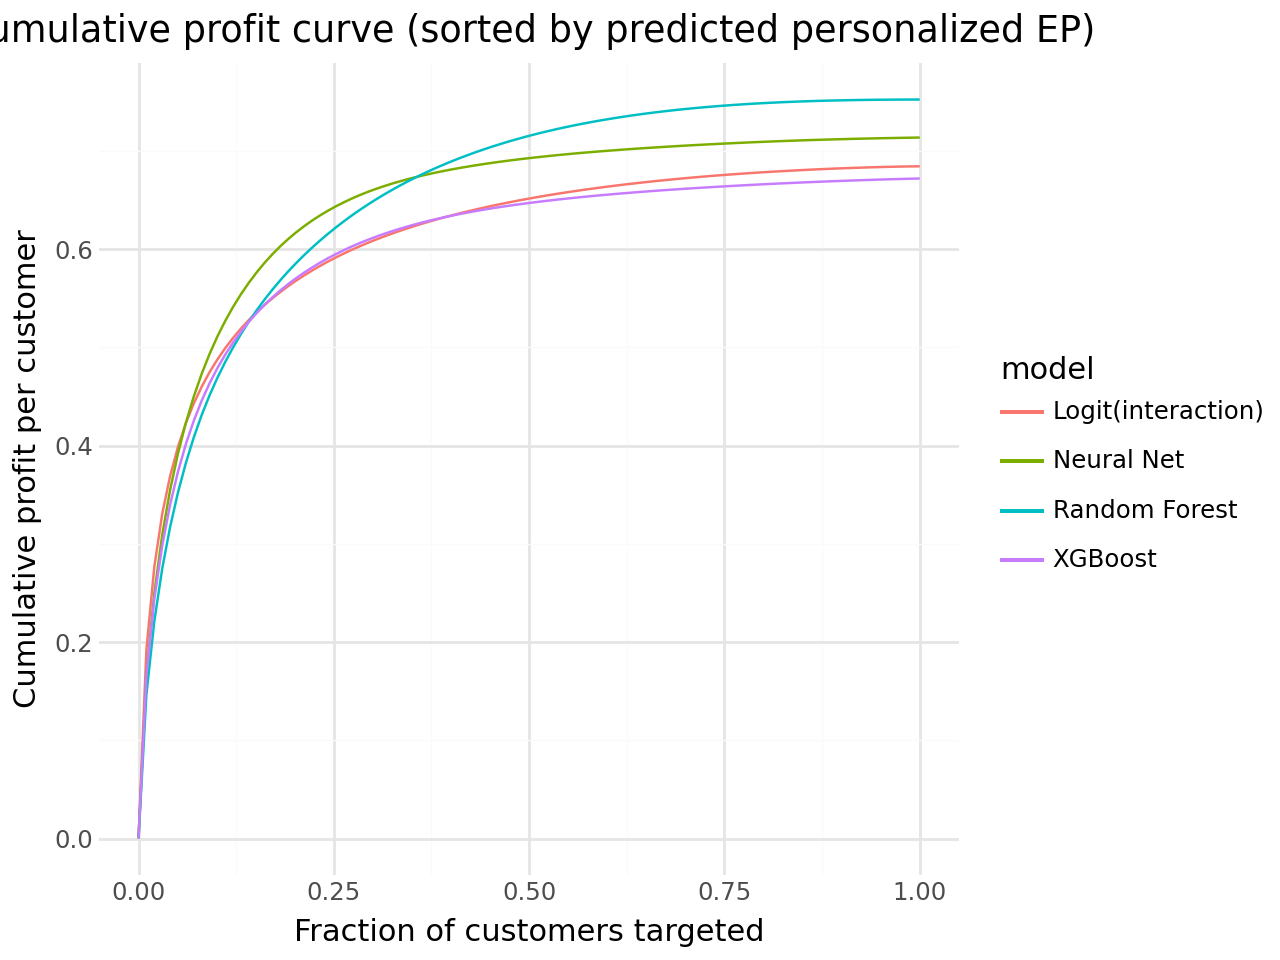

In [ ]:
from plotnine import ggplot, aes, geom_line, labs, theme_minimal
import polars as pl
import numpy as np

def profit_curve_pl(test_df: pl.DataFrame, col_name: str, model_name: str, n_points: int = 100):

    s = (
        test_df
        .select(pl.col(col_name))
        .sort(col_name, descending=True)
        .to_series()
        .to_numpy()
    )

    cum_profit = np.cumsum(s)
    cum_frac = np.arange(1, len(s) + 1) / len(s)

    idx = np.linspace(0, len(s) - 1, n_points).astype(int)

    return pl.DataFrame({
        "fraction_customers": cum_frac[idx],
        "cum_profit_per_customer": cum_profit[idx] / len(s),
        "model": [model_name] * len(idx)
    })

df_plot = pl.concat([
    profit_curve_pl(test_df, "ep_personalized", "Logit(interaction)"),
    profit_curve_pl(test_df, "ep_personalized_nn", "Neural Net"),
    profit_curve_pl(test_df, "best_ep_value_rf", "Random Forest"),
    profit_curve_pl(test_df, "ep_personalized_xgb", "XGBoost"),
])

(
    ggplot(df_plot, aes(x="fraction_customers", y="cum_profit_per_customer", color="model"))
    + geom_line()
    + theme_minimal()
    + labs(
        title="Cumulative profit curve (sorted by predicted personalized EP)",
        x="Fraction of customers targeted",
        y="Cumulative profit per customer"
    )
)

# Comment on the new proposal

The proposed policy moves in the right direction because it uses model-based expected profit to guide message allocation. However, it is not fully profit-maximizing.

One weakness is the fixed 50/50 split between the top two messages for each customer. In many cases, the top message may generate significantly higher expected profit than the second-best option. Forcing an equal split could reduce overall profitability, especially when the gap between the first and second message is large.

Another limitation is that the policy does not clearly incorporate the no-message (control) option as part of the decision rule. Our results show that for some customers, not sending an email may actually be the most profitable action. Excluding this option could lower total profit.

A possible improvement would be to allocate emails based directly on the highest expected profit for each customer, rather than splitting evenly between the top two messages. If department-level balance is required, the company could instead use an optimization approach that maximizes total expected profit subject to quota constraints, rather than applying a rigid 50/50 rule.

Overall, while the proposal improves upon a random allocation policy, it can be further refined to better align with the goal of maximizing expected profit.